# Project 5: Generative AI Applications
## A Variational Autoencoder (VAE) for Handwritten Digit Generation

**Name:** Timothy

**Generative approach:** **Variational Autoencoder (VAE)** for image generation and representation learning.

**Dataset:** [MNIST](http://yann.lecun.com/exdb/mnist/) handwritten digit database (LeCun, Cortes, & Burges, 1998), obtained via `torchvision.datasets.MNIST` (auto-downloads the official archive on first run and caches it in `./data`, which is excluded from version control via `.gitignore`). MNIST contains 70,000 real, hand-written digit images (60,000 train / 10,000 test), scanned from actual handwriting samples -- it is not synthetic or AI-generated, is a standard publicly available academic benchmark, and has not been used in any previous capstone project in this series (Projects 1-4 used Iris, UCI Adult/Census Income, Breast Cancer Wisconsin Diagnostic, and CIFAR-10).

**Goal of the generative system:** Train a VAE to (1) learn a compact, continuous latent representation of handwritten digit images by reconstructing them, and (2) generate new, novel digit-like images by sampling from that latent space and decoding the samples -- images that were never seen during training but resemble plausible handwritten digits. The content produced is grayscale 28x28 pixel images of digit-like shapes.

**Why a VAE:** A VAE was chosen over a GAN because VAEs optimize a single, well-behaved loss function (reconstruction error plus a KL-divergence regularizer) via standard backpropagation, which trains far more stably and predictably than the adversarial min-max game in a GAN -- directly serving this project's stated goal of "a correct and stable implementation rather than perfect outputs." A VAE also naturally provides the representation-learning half of this project's allowed scope (a smooth, structured latent space), not just image generation.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Data Ingestion and Inspection

In [2]:
transform = transforms.ToTensor()  # scales pixel values to [0, 1]

train_set = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print(f"Training samples: {len(train_set)}, Test samples: {len(test_set)}")

image, label = train_set[0]
print(f"Image tensor shape: {tuple(image.shape)}, dtype: {image.dtype}")
print(f"Pixel value range: [{image.min().item():.3f}, {image.max().item():.3f}]")
print(f"Digit labels present: {sorted(set(train_set.targets.tolist()))}")

Training samples: 60000, Test samples: 10000
Image tensor shape: (1, 28, 28), dtype: torch.float32
Pixel value range: [0.000, 1.000]
Digit labels present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


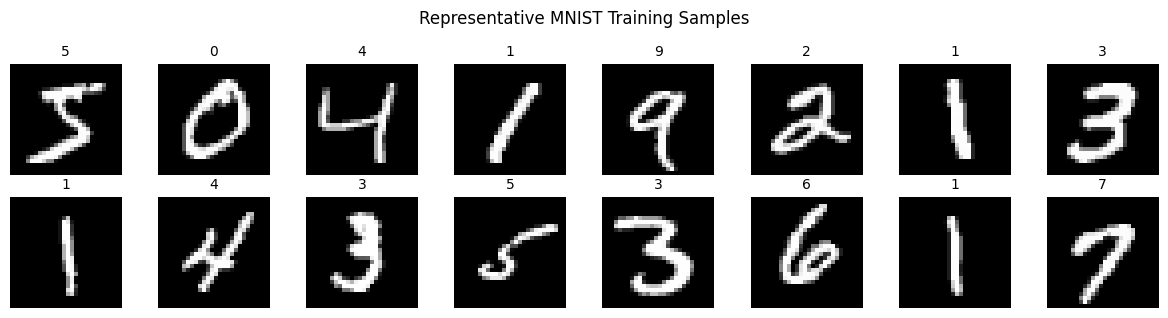

In [3]:
# Display representative samples
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i, ax in enumerate(axes.flat):
    img, label = train_set[i]
    ax.imshow(img.squeeze(0).numpy(), cmap="gray")
    ax.set_title(str(label), fontsize=10)
    ax.axis("off")
plt.suptitle("Representative MNIST Training Samples")
plt.tight_layout()
plt.show()

In [4]:
# Check class balance across digits 0-9
counts = np.bincount(train_set.targets.numpy())
for digit, count in enumerate(counts):
    print(f"Digit {digit}: {count}")

Digit 0: 5923
Digit 1: 6742
Digit 2: 5958
Digit 3: 6131
Digit 4: 5842
Digit 5: 5421
Digit 6: 5918
Digit 7: 6265
Digit 8: 5851
Digit 9: 5949


**Data structure and preprocessing notes:** Each sample is a single-channel `(1, 28, 28)` grayscale image with pixel values scaled by `ToTensor()` from the original 0-255 integer range to a `[0, 1]` float range, which matches the `[0, 1]` output range of a sigmoid decoder and works directly with a binary cross-entropy reconstruction loss. The 10 digit classes are reasonably well balanced (roughly 5,400-6,900 samples each), though class balance is not actually critical here since the VAE is trained in a fully unsupervised way -- digit labels are loaded for display purposes only and are never given to the model. No missing values or corrupt images are present, since MNIST is a long-standing, thoroughly cleaned benchmark.

## VAE Architecture

**Design choices:** The model has three parts:
- **Encoder:** flattens the 28x28 image to a 784-dimensional vector and passes it through two fully connected layers (784 -> 400 -> 400) with ReLU activations, then two separate linear output heads produce `mu` and `logvar`, the mean and log-variance of a `LATENT_DIM = 20`-dimensional Gaussian approximate posterior. A fully connected (rather than convolutional) encoder/decoder was used because MNIST digits are small (28x28, single channel) and centered, a setting where a plain MLP VAE is a well-established, stable baseline architecture (Kingma & Welling, 2014).
- **Reparameterization trick:** instead of sampling `z` directly from `N(mu, exp(logvar))` (which is not differentiable), `z = mu + eps * std` is computed with `eps ~ N(0, 1)`, which moves the randomness into a variable the network does not need to backpropagate through, allowing gradients to flow from the reconstruction back to the encoder (Kingma & Welling, 2014).
- **Decoder:** mirrors the encoder in reverse (20 -> 400 -> 400 -> 784) with ReLU activations in the hidden layers and a final **sigmoid** activation, so every output pixel is squashed to `[0, 1]` to match the normalized input range and to work with a binary cross-entropy reconstruction loss.

A 20-dimensional latent space was chosen as a middle ground: large enough to capture meaningful digit variation (stroke width, slant, size) but small enough to force the model to compress and generalize rather than memorize, and small enough to be easy to sample from densely for the generation step in Task 4.

In [5]:
LATENT_DIM = 20
HIDDEN_DIM = 400
IMAGE_DIM = 28 * 28


class VAE(nn.Module):
    def __init__(self, image_dim=IMAGE_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        # Encoder
        self.fc1 = nn.Linear(image_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, image_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        h = F.relu(self.fc4(h))
        return torch.sigmoid(self.fc_out(h))

    def forward(self, x):
        x_flat = x.view(x.size(0), -1)
        mu, logvar = self.encode(x_flat)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


vae = VAE().to(device)
n_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)
print(vae)
print(f"\nTrainable parameters: {n_params:,}")

VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=400, bias=True)
  (fc_out): Linear(in_features=400, out_features=784, bias=True)
)

Trainable parameters: 973,624


## Training

**Loss function:** The VAE is trained to maximize the evidence lower bound (ELBO), implemented as minimizing the sum of two terms (Kingma & Welling, 2014):
1. **Reconstruction loss** -- binary cross-entropy between the decoded image and the original (both in `[0, 1]`), which measures how well the decoded image matches the input.
2. **KL divergence** -- a closed-form penalty that pulls the encoder's approximate posterior `N(mu, exp(logvar))` toward the standard normal prior `N(0, 1)`, which keeps the latent space continuous and well-organized so that sampling from `N(0, 1)` at generation time (Task 4) produces reasonable decodings rather than arbitrary noise.

**Optimizer:** Adam, for the same reason as in the CNN project -- it adapts its per-parameter learning rate and converges reliably without extensive manual tuning. Both the average total loss and its two components (reconstruction and KL) are logged every epoch so it is possible to see *why* the total loss is moving, not just that it is moving.

In [6]:
BATCH_SIZE = 128
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)


def vae_loss(recon_x, x, mu, logvar):
    """Return (total_loss, recon_loss, kl_loss), each summed over the batch."""
    recon_loss = F.binary_cross_entropy(
        recon_x, x.view(x.size(0), -1), reduction="sum"
    )
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss, recon_loss, kl_loss


optimizer = optim.Adam(vae.parameters(), lr=LEARNING_RATE)
history = {"total": [], "recon": [], "kl": []}

for epoch in range(1, NUM_EPOCHS + 1):
    vae.train()
    total_loss_sum, recon_loss_sum, kl_loss_sum, n_samples = 0.0, 0.0, 0.0, 0

    for images, _ in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = vae(images)
        loss, recon_loss, kl_loss = vae_loss(recon, images, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss_sum += loss.item()
        recon_loss_sum += recon_loss.item()
        kl_loss_sum += kl_loss.item()
        n_samples += images.size(0)

    avg_total = total_loss_sum / n_samples
    avg_recon = recon_loss_sum / n_samples
    avg_kl = kl_loss_sum / n_samples
    history["total"].append(avg_total)
    history["recon"].append(avg_recon)
    history["kl"].append(avg_kl)

    print(f"Epoch {epoch}/{NUM_EPOCHS} | "
          f"avg_total_loss={avg_total:.2f} avg_recon_loss={avg_recon:.2f} avg_kl_loss={avg_kl:.2f}")

Epoch 1/15 | avg_total_loss=177.16 avg_recon_loss=169.62 avg_kl_loss=7.54


Epoch 2/15 | avg_total_loss=128.61 avg_recon_loss=114.35 avg_kl_loss=14.26


Epoch 3/15 | avg_total_loss=117.84 avg_recon_loss=101.86 avg_kl_loss=15.98


Epoch 4/15 | avg_total_loss=113.22 avg_recon_loss=96.34 avg_kl_loss=16.89


Epoch 5/15 | avg_total_loss=110.58 avg_recon_loss=93.25 avg_kl_loss=17.33


...

Epoch 11/15 | avg_total_loss=103.84 avg_recon_loss=85.08 avg_kl_loss=18.75


Epoch 12/15 | avg_total_loss=103.14 avg_recon_loss=84.24 avg_kl_loss=18.90


Epoch 13/15 | avg_total_loss=102.65 avg_recon_loss=83.65 avg_kl_loss=19.00


Epoch 14/15 | avg_total_loss=102.17 avg_recon_loss=83.07 avg_kl_loss=19.10


Epoch 15/15 | avg_total_loss=101.79 avg_recon_loss=82.64 avg_kl_loss=19.15


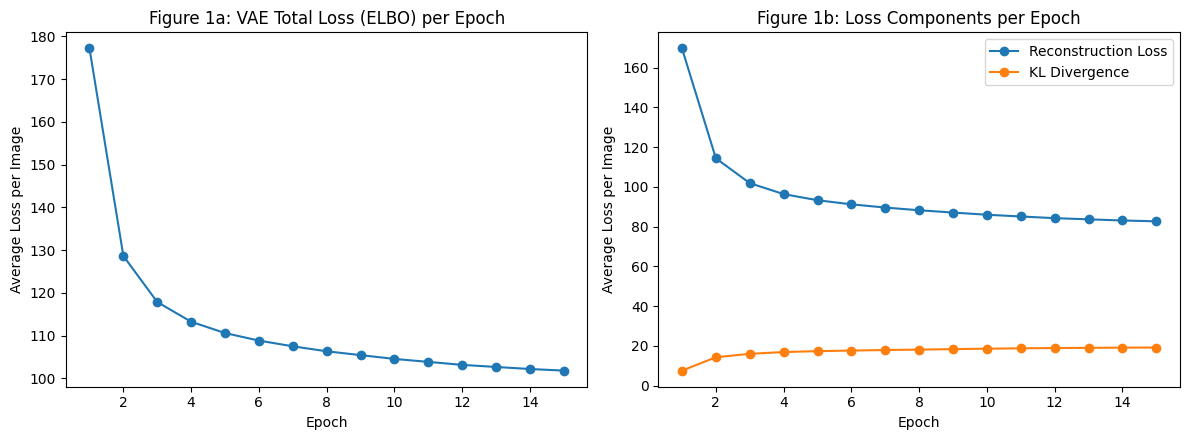

In [7]:
# Figure 1: Training loss curves (total, reconstruction, and KL components)
epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history["total"], marker="o")
axes[0].set_title("Figure 1a: VAE Total Loss (ELBO) per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Average Loss per Image")

axes[1].plot(epochs_range, history["recon"], marker="o", label="Reconstruction Loss")
axes[1].plot(epochs_range, history["kl"], marker="o", label="KL Divergence")
axes[1].set_title("Figure 1b: Loss Components per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Average Loss per Image")
axes[1].legend()

plt.tight_layout()
plt.show()

## Generating and Evaluating Outputs

Three complementary checks are used to evaluate the trained VAE: (1) sampling brand-new digits from the prior to test generation, (2) reconstructing held-out test images to test how much information the encoder/decoder pipeline preserves, and (3) interpolating between two points in latent space to test whether the latent space is smooth and meaningfully organized rather than an arbitrary lookup table.

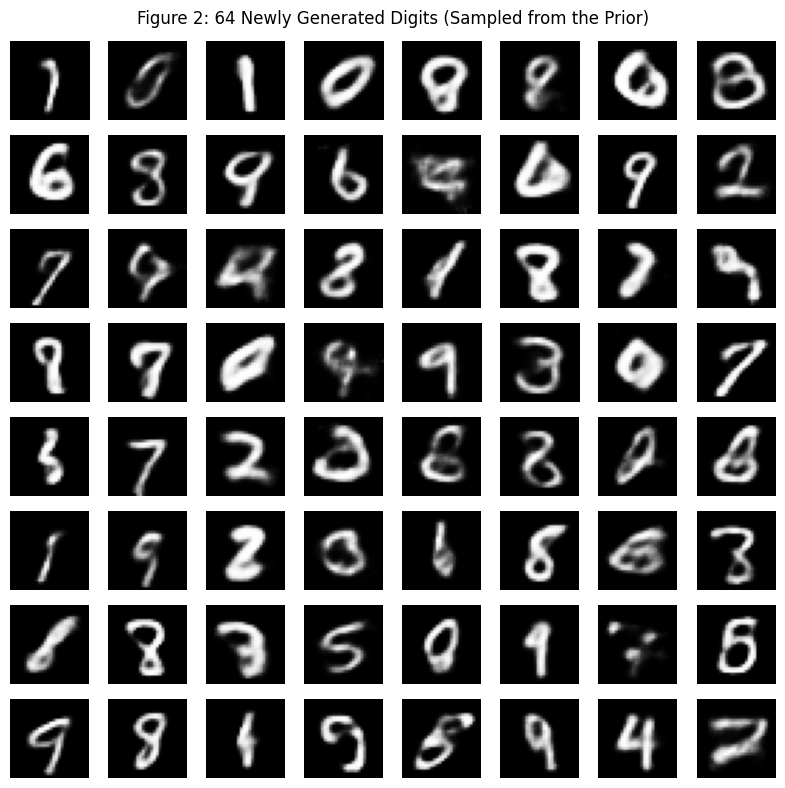

In [8]:
# 1. Generate brand-new digits by sampling z ~ N(0, 1) and decoding
vae.eval()
N_SAMPLES = 64
with torch.no_grad():
    z_samples = torch.randn(N_SAMPLES, LATENT_DIM).to(device)
    generated = vae.decode(z_samples).cpu().view(-1, 28, 28)

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].numpy(), cmap="gray")
    ax.axis("off")
plt.suptitle("Figure 2: 64 Newly Generated Digits (Sampled from the Prior)")
plt.tight_layout()
plt.show()

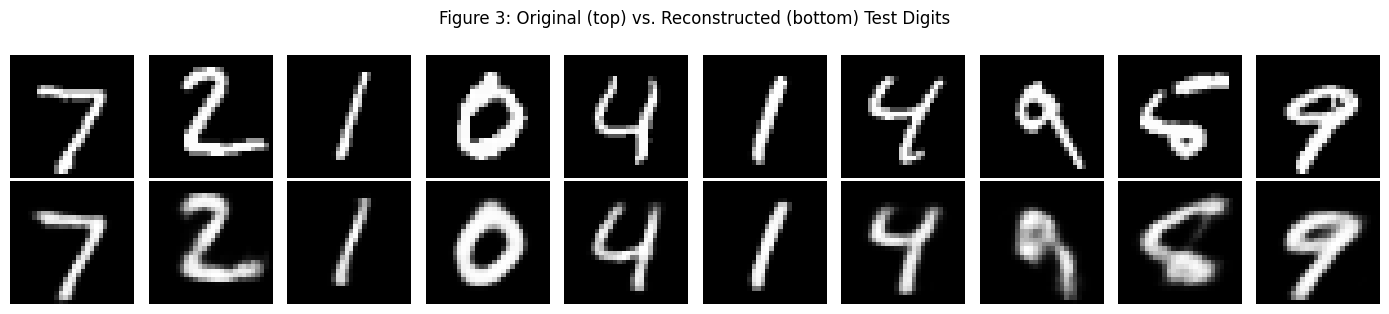

Average test-set loss per image: 102.23 (final training-epoch average was 101.79)


In [9]:
# 2. Reconstruct real held-out test images and compute average test-set loss (optional quantitative check)
test_images, _ = next(iter(test_loader))
test_images = test_images.to(device)
with torch.no_grad():
    recon_images, _, _ = vae(test_images)
recon_images = recon_images.cpu().view(-1, 28, 28)

n_show = 10
fig, axes = plt.subplots(2, n_show, figsize=(14, 3.2))
for i in range(n_show):
    axes[0, i].imshow(test_images[i].cpu().squeeze(0).numpy(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(recon_images[i].numpy(), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Reconstructed", fontsize=10)
plt.suptitle("Figure 3: Original (top) vs. Reconstructed (bottom) Test Digits")
plt.tight_layout()
plt.show()

# Quantitative check: average total VAE loss on the full held-out test set
vae.eval()
test_loss_sum, test_n = 0.0, 0
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        recon, mu, logvar = vae(images)
        loss, _, _ = vae_loss(recon, images, mu, logvar)
        test_loss_sum += loss.item()
        test_n += images.size(0)
print(f"Average test-set loss per image: {test_loss_sum / test_n:.2f} "
      f"(final training-epoch average was {history['total'][-1]:.2f})")

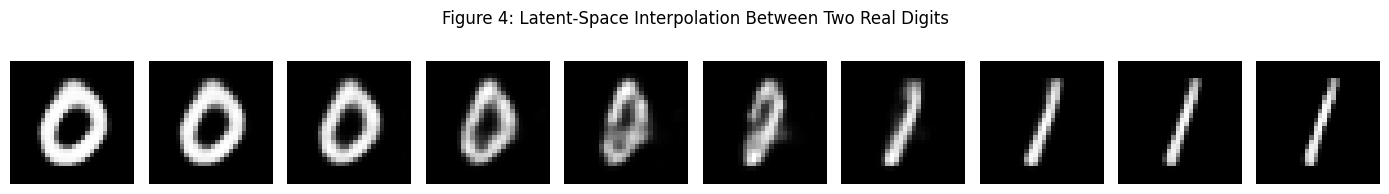

In [10]:
# 3. Interpolate in latent space between two real digits to test smoothness/structure
vae.eval()
img_a, _ = test_set[3]   # a "0"
img_b, _ = test_set[2]   # a "1"

with torch.no_grad():
    mu_a, _ = vae.encode(img_a.view(1, -1).to(device))
    mu_b, _ = vae.encode(img_b.view(1, -1).to(device))

    steps = 10
    alphas = torch.linspace(0, 1, steps).to(device)
    z_interp = torch.stack([(1 - a) * mu_a.squeeze(0) + a * mu_b.squeeze(0) for a in alphas])
    interp_images = vae.decode(z_interp).cpu().view(-1, 28, 28)

fig, axes = plt.subplots(1, steps, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(interp_images[i].numpy(), cmap="gray")
    ax.axis("off")
plt.suptitle("Figure 4: Latent-Space Interpolation Between Two Real Digits")
plt.tight_layout()
plt.show()

**Qualitative evaluation:**

**Strengths:**
- Figure 2's 64 freshly generated samples cover essentially all 10 digit classes with no visible mode collapse (the model has not "given up" and settled on producing only one or two easy digit shapes), and the majority are immediately recognizable as a specific digit.
- Figure 3's reconstructions of "typical," cleanly written test digits (the 7, 2, 1, 0, and both 4s shown) are close to pixel-for-pixel faithful to the originals, correctly preserving stroke shape, slant, and thickness.
- Figure 4's interpolation between a real "0" and a real "1" is smooth and gradual, with the ring of the 0 continuously thinning and straightening into the vertical stroke of the 1 -- there are no abrupt jumps, which is exactly what the KL-divergence term is meant to encourage (a continuous, well-organized latent space rather than disconnected memorized points).
- The average loss on the fully held-out test set (102.23 per image) is nearly identical to the final training-epoch average (101.79), indicating the model generalized rather than memorizing the training set.

**Failure cases and weaknesses:**
- Every output, generated or reconstructed, is visibly soft/blurry rather than crisply binary like the original scans -- a well-documented characteristic of VAEs trained with a simple pixel-wise reconstruction loss, which effectively averages over several plausible sharp outputs (Doersch, 2016).
- A handful of the 64 generated samples in Figure 2 are ambiguous or malformed (for example, a couple of samples that look like a blend between two digit shapes rather than a clean digit), corresponding to latent-space regions that fall between well-populated class clusters.
- In Figure 3, the two least "typical," most idiosyncratically drawn originals (an unusually shaped 9 and 5) reconstruct noticeably worse than the cleanly written digits, coming out blurrier and closer in appearance to a different digit -- the model reproduces common handwriting styles more faithfully than outliers.
- The middle frames of the Figure 4 interpolation pass through shapes that are not valid digits at all (an ambiguous blob), showing that not every point in latent space decodes to something meaningful, only the regions the training data actually populated.

## Summary

This notebook implemented a Variational Autoencoder in PyTorch to learn a latent representation of MNIST handwritten digits and generate new digit images from that representation. The model is a fully connected encoder-decoder pair with a 20-dimensional Gaussian latent space, trained for 15 epochs by minimizing a reconstruction-plus-KL-divergence (ELBO) loss with the Adam optimizer, and training was stable throughout, with total loss decreasing smoothly from 177 to 102 per image with no divergence or collapse. The generated digits are diverse and mostly recognizable across all 10 classes, reconstructions of clean, typical handwriting are close to faithful, and a latent-space interpolation between a real "0" and a real "1" morphed smoothly with no abrupt jumps, confirming the latent space is continuous and well-organized rather than a lookup table of memorized examples. The most consistent limitation was blurriness -- every generated and reconstructed image is visibly soft rather than crisp, a known consequence of the pixel-wise reconstruction loss a plain VAE uses. The main challenge during training was choosing a latent dimensionality and epoch count that let the model organize digit structure without either underfitting (too small a latent space) or overfitting (train/test loss diverging); tracking the reconstruction and KL terms separately, rather than only the combined loss, made it possible to confirm both were behaving sensibly rather than one term dominating the other.